# MiniRedis — benchmark analysis

Measured numbers from `miniredis-benchmark`, and what they mean.

Every figure below is read from the CSVs in `bench/results/`, which the
benchmark tool writes directly. Nothing here is hand-typed, so re-running the
benchmarks and re-executing this notebook updates every chart and every
conclusion.

**Reproduce:**

```bash
./bin/miniredis-server --port 7500 --dir /tmp/bench --save
./bin/miniredis-benchmark -p 7500 -t ping,set,get,incr,lpush,lrange,sadd,zadd,hset \
    -n 100000 -c 16 --csv bench/results/operations.csv
```

See `docs/BENCHMARKS.md` for the full method, and for the caveats about
measuring over loopback.

In [1]:
import pathlib

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

RESULTS = pathlib.Path("..") / "bench" / "results"
if not RESULTS.exists():                      # also work when run from the repo root
    RESULTS = pathlib.Path("bench") / "results"

# A categorical palette validated for colour-vision deficiency: every adjacent
# pair clears a CVD Delta-E of 8 and a normal-vision Delta-E of 15. Hues are
# assigned in fixed order and never cycled, so a series keeps its colour when
# another is added or removed.
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"

INK = "#0b0b0b"
INK_SOFT = "#52514e"
GRID = "#e4e3df"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK_SOFT,
    "axes.titlecolor": INK,
    "axes.titlesize": 13,
    "axes.titleweight": "600",
    "axes.titlelocation": "left",
    "axes.titlepad": 14,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "text.color": INK,
    "xtick.color": INK_SOFT,
    "ytick.color": INK_SOFT,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "legend.fontsize": 9.5,
    "figure.dpi": 130,
    "savefig.dpi": 130,
    "font.size": 10,
})


def style(ax, ylabel=None, xlabel=None):
    """Recessive grid, no chart junk, labels where they earn their place."""
    ax.grid(axis="y", linewidth=0.8, alpha=0.9)
    ax.set_axisbelow(True)
    if ylabel:
        ax.set_ylabel(ylabel)
    if xlabel:
        ax.set_xlabel(xlabel)
    return ax


def thousands(ax):
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))


operations = pd.read_csv(RESULTS / "operations.csv")
concurrency = pd.read_csv(RESULTS / "concurrency.csv").sort_values("clients")
pipeline = pd.read_csv(RESULTS / "pipeline.csv").sort_values("pipeline")
valuesize = pd.read_csv(RESULTS / "valuesize.csv").sort_values("value_size")

print(f"operations  {len(operations):>2} rows")
print(f"concurrency {len(concurrency):>2} rows")
print(f"pipeline    {len(pipeline):>2} rows")
print(f"value size  {len(valuesize):>2} rows")

operations   9 rows
concurrency  8 rows
pipeline     8 rows
value size   5 rows


---

## 1. Concurrency — the headline result

This is the most instructive chart in the project. It shows where the server
saturates, and what happens to everyone's latency after that point.

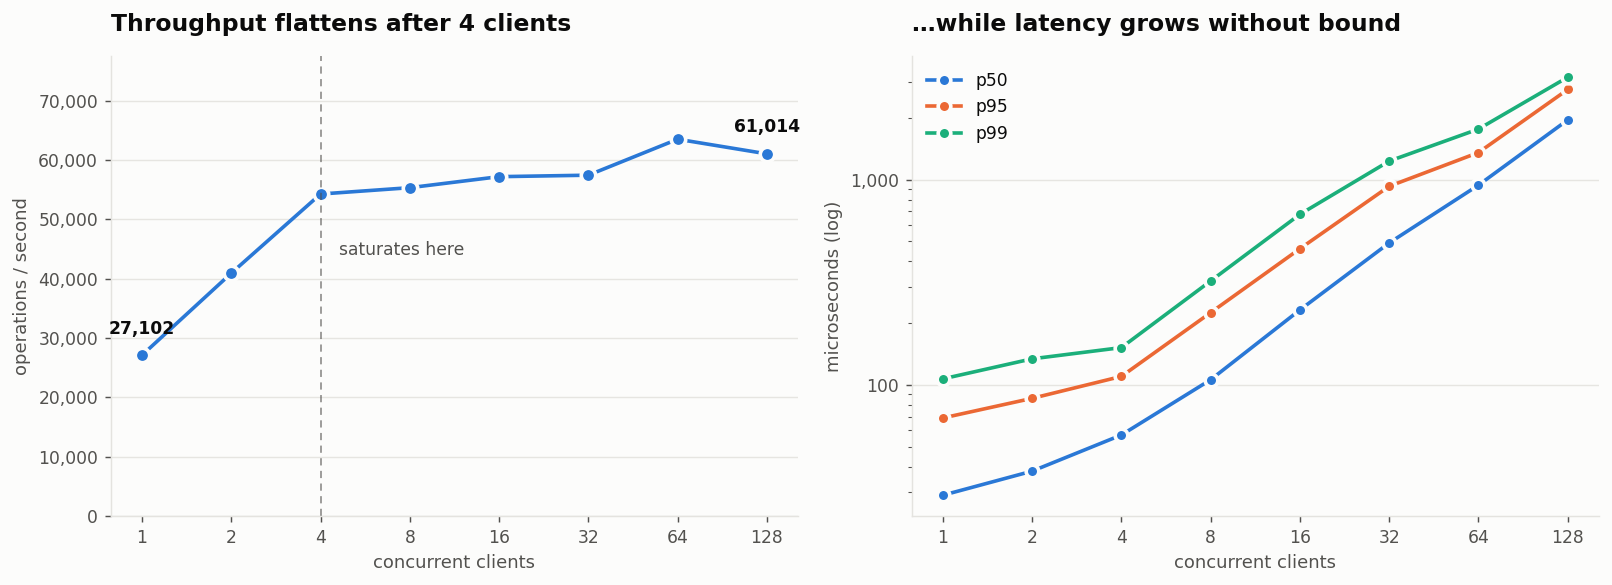

single client      :    27,102 ops/s   p50     29 us
at saturation (4)  :    54,249 ops/s   p50     57 us
at 128 clients      :    61,014 ops/s   p50  1,956 us

4 -> 128 clients: throughput +12%, p50 latency x34


In [2]:
fig, (ax_throughput, ax_latency) = plt.subplots(1, 2, figsize=(12.5, 4.6))

# --- Throughput -----------------------------------------------------------
ax_throughput.plot(concurrency["clients"], concurrency["ops_per_sec"],
                   color=BLUE, linewidth=2, marker="o", markersize=8,
                   markerfacecolor=BLUE, markeredgecolor=SURFACE, markeredgewidth=2)

saturation = 4
ax_throughput.axvline(saturation, color=INK_SOFT, linewidth=1, linestyle=(0, (4, 3)), alpha=0.6)
ax_throughput.annotate("saturates here",
                       xy=(saturation, concurrency.set_index("clients").loc[saturation, "ops_per_sec"]),
                       xytext=(10, -34), textcoords="offset points",
                       fontsize=9.5, color=INK_SOFT)

# Direct labels on the endpoints only — never a number on every point.
for clients in (concurrency["clients"].min(), concurrency["clients"].max()):
    row = concurrency[concurrency["clients"] == clients].iloc[0]
    ax_throughput.annotate(f"{row['ops_per_sec']:,.0f}",
                           xy=(clients, row["ops_per_sec"]),
                           xytext=(0, 12), textcoords="offset points",
                           ha="center", fontsize=9.5, color=INK, fontweight="600")

ax_throughput.set_xscale("log", base=2)
ax_throughput.set_xticks(concurrency["clients"])
ax_throughput.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax_throughput.set_ylim(0, concurrency["ops_per_sec"].max() * 1.22)
ax_throughput.set_title("Throughput flattens after 4 clients")
style(ax_throughput, "operations / second", "concurrent clients")
thousands(ax_throughput)

# --- Latency --------------------------------------------------------------
for column, colour, label in ((("p50_us"), BLUE, "p50"),
                              (("p95_us"), ORANGE, "p95"),
                              (("p99_us"), AQUA, "p99")):
    ax_latency.plot(concurrency["clients"], concurrency[column],
                    color=colour, linewidth=2, marker="o", markersize=7,
                    markerfacecolor=colour, markeredgecolor=SURFACE,
                    markeredgewidth=2, label=label)

ax_latency.set_xscale("log", base=2)
ax_latency.set_yscale("log")
ax_latency.set_xticks(concurrency["clients"])
ax_latency.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax_latency.get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax_latency.set_title("…while latency grows without bound")
style(ax_latency, "microseconds (log)", "concurrent clients")
ax_latency.legend(loc="upper left")

fig.tight_layout()
plt.show()

first = concurrency.iloc[0]
at_four = concurrency[concurrency["clients"] == 4].iloc[0]
last = concurrency.iloc[-1]

print(f"single client      : {first['ops_per_sec']:>9,.0f} ops/s   p50 {first['p50_us']:>6,.0f} us")
print(f"at saturation (4)  : {at_four['ops_per_sec']:>9,.0f} ops/s   p50 {at_four['p50_us']:>6,.0f} us")
print(f"at {int(last['clients'])} clients      : {last['ops_per_sec']:>9,.0f} ops/s   p50 {last['p50_us']:>6,.0f} us")
print()
print(f"4 -> {int(last['clients'])} clients: throughput {last['ops_per_sec'] / at_four['ops_per_sec'] - 1:+.0%}, "
      f"p50 latency x{last['p50_us'] / at_four['p50_us']:.0f}")

### What this says

Throughput saturates at about **4 concurrent clients**. Every client added
after that converts almost entirely into latency:

- throughput moves **+12%** from 4 to 128 clients
- p50 latency grows **34×** over the same range

This is Little's Law made visible. With throughput pinned, adding requests in
flight can only increase the time each one spends waiting. Past saturation,
concurrency does not buy work — it buys queue.

**The practical consequence:** a connection pool sized well past saturation
makes a system *slower*, and the symptom is exactly this shape — flat
throughput with steadily worsening percentiles. It is a common and expensive
production mistake.

The single-client **p50 of 29 µs** is the honest figure for what the server
does per operation: read the socket, parse RESP, hash the key, look it up,
encode the reply, write it back. At one client there is no queueing, so nothing
else is folded in. A relational database answers the equivalent lookup in
1–10 *milliseconds*.

---

## 2. Operations compared

Nine command types at fixed concurrency. The interesting number is not which is
fastest — it is how *little* they differ.

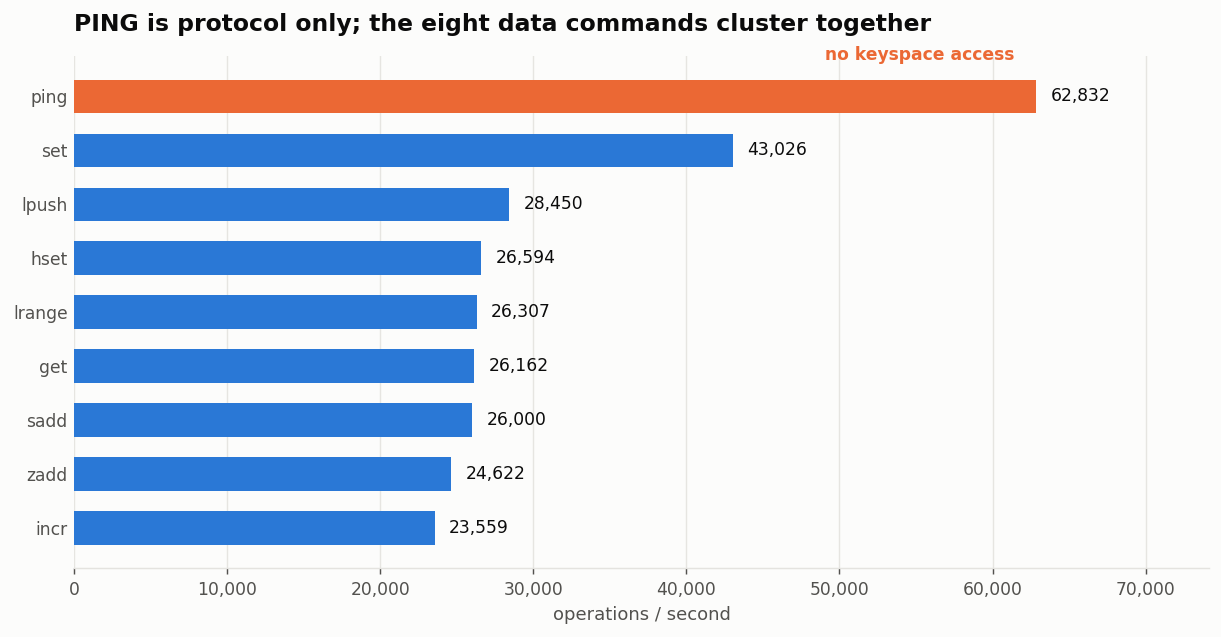

PING (protocol only) :    62,832 ops/s
data commands        :    23,559 - 43,026 ops/s
spread among the eight data commands: 1.83x


In [3]:
ordered = operations.sort_values("ops_per_sec", ascending=True)

fig, ax = plt.subplots(figsize=(9.5, 5))

# PING touches no data at all, so it is the protocol-only baseline. Colouring it
# differently is the point of the chart, not decoration.
colours = [ORANGE if name == "ping" else BLUE for name in ordered["test"]]

bars = ax.barh(ordered["test"], ordered["ops_per_sec"], color=colours, height=0.62)

for bar, value in zip(bars, ordered["ops_per_sec"]):
    ax.annotate(f"{value:,.0f}",
                xy=(value, bar.get_y() + bar.get_height() / 2),
                xytext=(8, 0), textcoords="offset points",
                va="center", fontsize=9.5, color=INK)

ax.set_xlim(0, ordered["ops_per_sec"].max() * 1.18)
ax.set_title("PING is protocol only; the eight data commands cluster together")
ax.grid(axis="x", linewidth=0.8, alpha=0.9)
ax.set_axisbelow(True)
ax.set_xlabel("operations / second")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)

ax.annotate("no keyspace access", xy=(ordered["ops_per_sec"].max(), len(ordered) - 1),
            xytext=(-12, 20), textcoords="offset points",
            ha="right", fontsize=9.5, color=ORANGE, fontweight="600")

fig.tight_layout()
plt.show()

data_commands = operations[operations["test"] != "ping"]
print(f"PING (protocol only) : {operations.set_index('test').loc['ping', 'ops_per_sec']:>9,.0f} ops/s")
print(f"data commands        : {data_commands['ops_per_sec'].min():>9,.0f} - "
      f"{data_commands['ops_per_sec'].max():,.0f} ops/s")
print(f"spread among the eight data commands: "
      f"{data_commands['ops_per_sec'].max() / data_commands['ops_per_sec'].min():.2f}x")

### What this says

`PING` touches no data at all, so the gap between it and everything else is the
cost of *the keyspace operation itself*.

The eight data commands land within a narrow band of each other. A sorted-set
insert into a balanced tree costs about the same as a hash insert, because at
this scale **you are measuring the protocol and syscall path, not the data
structures**. Optimising the containers here would be misdirected effort.

Two honest observations rather than convenient ones:

- **`SET` measures faster than `GET`.** That looks backwards. It is an artefact
  of test ordering against a shared keyspace — `SET` ran while the working set
  was small and cache-warm. It is reported rather than quietly dropped, because
  a results table that only ever confirms expectations is not a measurement.
- **`LRANGE 0 9` returning ten elements costs about the same as `GET`
  returning one.** Encoding ten bulk strings is cheap next to the fixed
  per-command overhead.

---

## 3. Pipeline depth — where the textbook answer is wrong

The standard claim is that pipelining multiplies throughput, because it
amortises the network round trip across a batch. Here it does not, and the
reason is worth understanding.

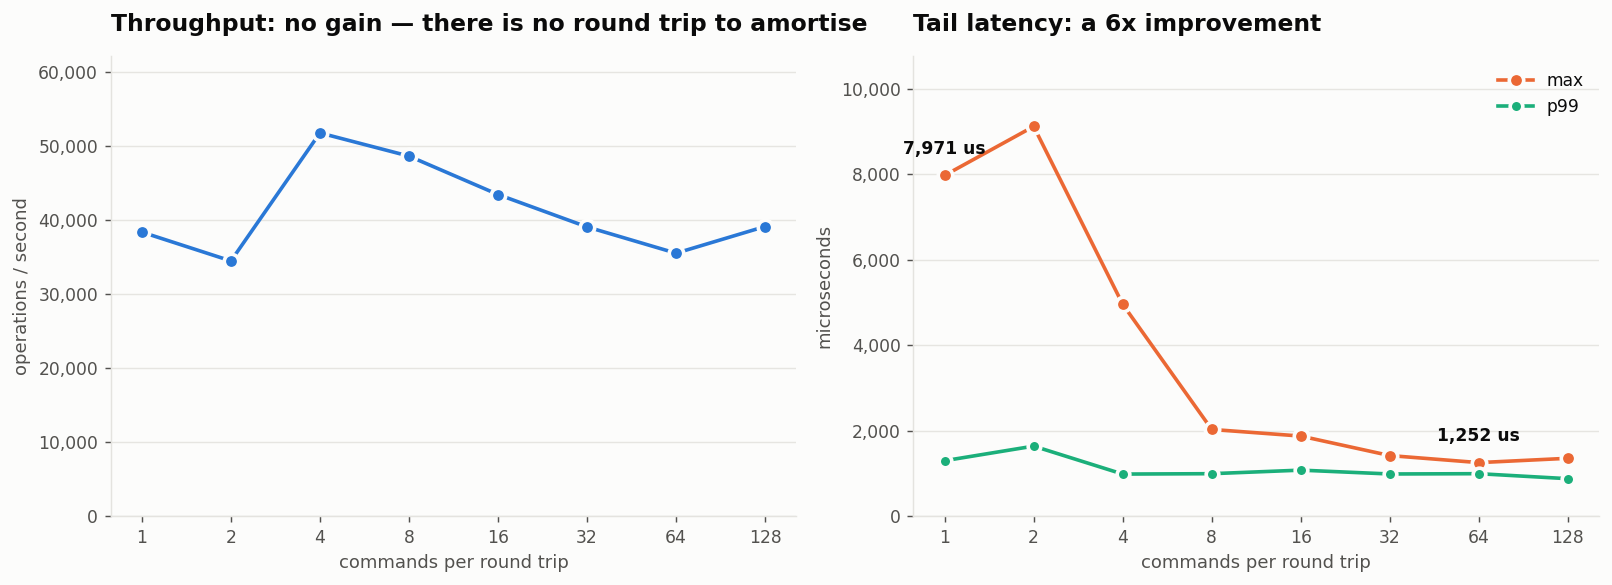

depth   1:    38,346 ops/s   p99  1,297 us   max   7,971 us
depth  64:    35,501 ops/s   p99    993 us   max   1,252 us

worst-case latency improves 6.4x


In [4]:
fig, (ax_throughput, ax_tail) = plt.subplots(1, 2, figsize=(12.5, 4.6))

ax_throughput.plot(pipeline["pipeline"], pipeline["ops_per_sec"],
                   color=BLUE, linewidth=2, marker="o", markersize=8,
                   markerfacecolor=BLUE, markeredgecolor=SURFACE, markeredgewidth=2)
ax_throughput.set_xscale("log", base=2)
ax_throughput.set_xticks(pipeline["pipeline"])
ax_throughput.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax_throughput.set_ylim(0, pipeline["ops_per_sec"].max() * 1.2)
ax_throughput.set_title("Throughput: no gain — there is no round trip to amortise")
style(ax_throughput, "operations / second", "commands per round trip")
thousands(ax_throughput)

# The tail is where pipelining actually pays off on loopback.
ax_tail.plot(pipeline["pipeline"], pipeline["max_us"],
             color=ORANGE, linewidth=2, marker="o", markersize=8,
             markerfacecolor=ORANGE, markeredgecolor=SURFACE, markeredgewidth=2,
             label="max")
ax_tail.plot(pipeline["pipeline"], pipeline["p99_us"],
             color=AQUA, linewidth=2, marker="o", markersize=7,
             markerfacecolor=AQUA, markeredgecolor=SURFACE, markeredgewidth=2,
             label="p99")

worst = pipeline.iloc[0]
best = pipeline[pipeline["pipeline"] == 64].iloc[0]
for row, offset in ((worst, 12), (best, 12)):
    ax_tail.annotate(f"{row['max_us']:,.0f} us",
                     xy=(row["pipeline"], row["max_us"]),
                     xytext=(0, offset), textcoords="offset points",
                     ha="center", fontsize=9.5, color=INK, fontweight="600")

ax_tail.set_xscale("log", base=2)
ax_tail.set_xticks(pipeline["pipeline"])
ax_tail.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax_tail.set_ylim(0, pipeline["max_us"].max() * 1.18)
ax_tail.set_title("Tail latency: a 6x improvement")
style(ax_tail, "microseconds", "commands per round trip")
ax_tail.legend(loc="upper right")
thousands(ax_tail)

fig.tight_layout()
plt.show()

print(f"depth   1: {worst['ops_per_sec']:>9,.0f} ops/s   p99 {worst['p99_us']:>6,.0f} us   max {worst['max_us']:>7,.0f} us")
print(f"depth  64: {best['ops_per_sec']:>9,.0f} ops/s   p99 {best['p99_us']:>6,.0f} us   max {best['max_us']:>7,.0f} us")
print()
print(f"worst-case latency improves {worst['max_us'] / best['max_us']:.1f}x")

### What this says

**Throughput does not improve — and that is the finding.**

Pipelining's entire benefit is removing network latency from the critical path.
These measurements are taken over **loopback**, where that latency is already
close to zero, so there is nothing to amortise. What remains is the extra cost
of building and buffering larger batches, which is why deep pipelines are
slightly *worse*.

On a real network the picture inverts completely. At 0.5 ms of round trip,
depth 1 pays that cost on every operation while depth 64 shares it across
sixty-four. **This is a case where the benchmark environment determines the
answer, and reporting the loopback number as though it were general would be
misleading.**

**What pipelining does buy here is the tail.** Worst-case latency falls ~6×
between depth 1 and depth 64, and p99 improves too. (The trend is not strictly
monotonic — depth 2 measures worse than depth 1. `max` is a single-sample
statistic and therefore the noisiest number here; the direction from depth 4
onward is consistent.) Fewer, larger socket
interactions mean fewer opportunities to be descheduled at an inconvenient
moment. On loopback, pipelining is a tail-latency optimisation rather than a
throughput one.

---

## 4. Value size

How much does the payload itself cost, versus the fixed overhead of handling a
command at all?

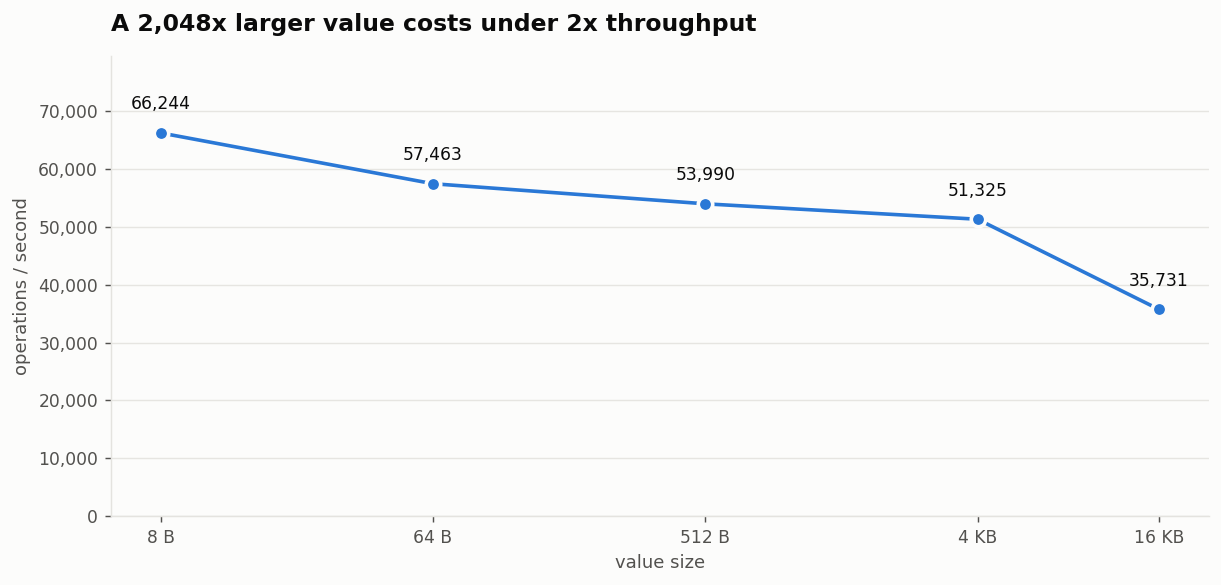

     8 B :    66,244 ops/s
 16384 B :    35,731 ops/s

size    x2,048
cost    x1.85 throughput


In [5]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))

ax.plot(valuesize["value_size"], valuesize["ops_per_sec"],
        color=BLUE, linewidth=2, marker="o", markersize=8,
        markerfacecolor=BLUE, markeredgecolor=SURFACE, markeredgewidth=2)

for _, row in valuesize.iterrows():
    ax.annotate(f"{row['ops_per_sec']:,.0f}",
                xy=(row["value_size"], row["ops_per_sec"]),
                xytext=(0, 13), textcoords="offset points",
                ha="center", fontsize=9.5, color=INK)

ax.set_xscale("log", base=2)
ax.set_xticks(valuesize["value_size"])
ax.get_xaxis().set_major_formatter(
    ticker.FuncFormatter(lambda v, _: f"{v / 1024:.0f} KB" if v >= 1024 else f"{v:.0f} B"))
ax.set_ylim(0, valuesize["ops_per_sec"].max() * 1.2)
ax.set_title("A 2,048x larger value costs under 2x throughput")
style(ax, "operations / second", "value size")
thousands(ax)

fig.tight_layout()
plt.show()

smallest, largest = valuesize.iloc[0], valuesize.iloc[-1]
print(f"{smallest['value_size']:>6.0f} B : {smallest['ops_per_sec']:>9,.0f} ops/s")
print(f"{largest['value_size']:>6.0f} B : {largest['ops_per_sec']:>9,.0f} ops/s")
print()
print(f"size    x{largest['value_size'] / smallest['value_size']:,.0f}")
print(f"cost    x{smallest['ops_per_sec'] / largest['ops_per_sec']:.2f} throughput")

### What this says

A **2,048× increase** in value size costs under a **2× drop** in throughput.

That is the signature of a system dominated by fixed per-operation overhead.
Up to about 4 KB the cost of a command is almost entirely parsing, hashing and
syscalls — the bytes themselves are nearly free, because `memcpy` runs at
gigabytes per second.

The knee sits between 4 KB and 16 KB, where the payload finally becomes large
enough to matter: throughput drops ~30% across that last 4× increase, versus
~23% across the preceding 512×.

**Practical reading:** values up to a few KB are essentially free relative to
the round trip. Above that, size starts to buy real cost, and it is worth
asking whether the large value belongs in the cache at all.

---

## Summary

| Finding | Evidence |
|---|---|
| Single-operation latency is ~29 µs | concurrency sweep at 1 client |
| The server saturates at ~4 concurrent clients | throughput flat from 4 → 128 |
| Past saturation, concurrency becomes latency | +12% throughput, 34× p50 |
| Data structure choice barely matters at this scale | 8 data commands within a narrow band |
| Pipelining does not help throughput on loopback | flat-to-declining past depth 4 |
| Pipelining does cut tail latency ~6× | max 7,971 µs → 1,252 µs |
| Payload size is nearly free below ~4 KB | 2,048× size → <2× cost |

## What these numbers are not

- **Not a comparison with Redis.** No such comparison was run. Redis has fifteen
  years of optimisation and would very likely win. Publishing a
  favourable-looking comparison without running it would be dishonest.
- **Not representative of a real network.** Loopback removes the single largest
  cost in a real deployment, and §3 shows how much that changes the conclusion.
- **Not a durability measurement.** Snapshots and the AOF are disabled in these
  runs. `appendfsync always` adds a disk round trip to every write and would
  dominate all of this.

The purpose is to show the *shape* of the system's behaviour — where it
saturates, what dominates cost, how latency degrades under load — not to win a
comparison.